<a href="https://colab.research.google.com/github/sasvi123/Neural_Network/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AND Gate Accuracy: 100.0%


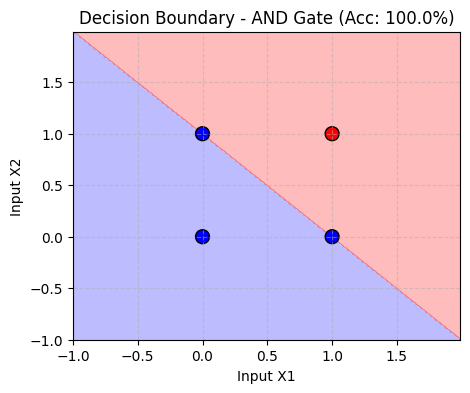

OR Gate Accuracy: 100.0%


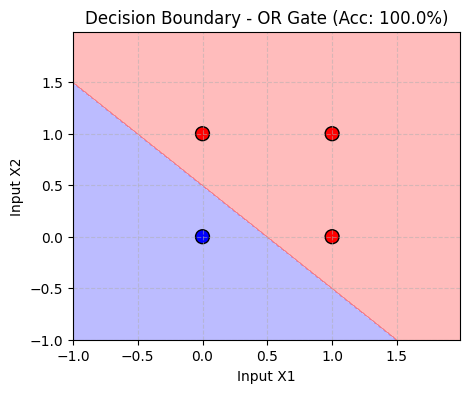

NOT Gate Accuracy: 100.0%


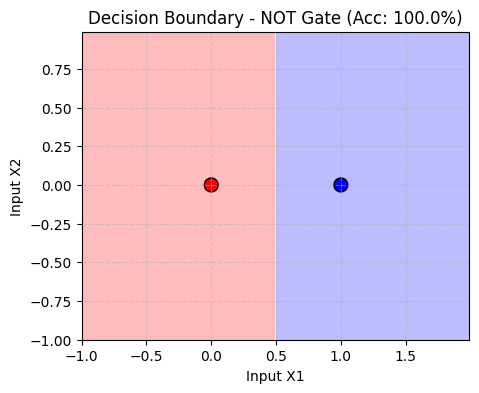

XOR Gate Accuracy: 50.0%


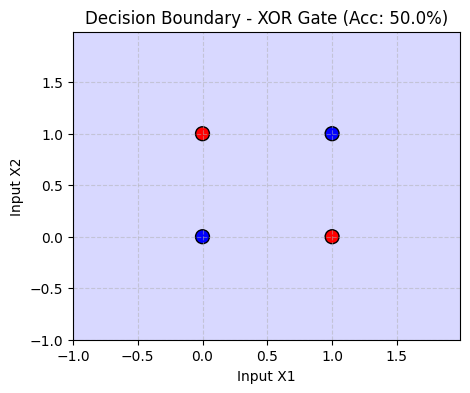

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
# Helper function to run, evaluate, and plot logic gates
def train_and_plot_gate(gate_name, X, y):
    #Step 1: Train the Perceptron
    # Initialize and fit the Scikit-Learn Perceptron
    model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
    model.fit(X, y)

    #Step 2:  Evaluate performance
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"{gate_name} Gate Accuracy: {acc * 100}%")

    # Generate mesh coordinates for drawing the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Classify mesh points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Generate plot
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolor='k', cmap='bwr')
    plt.title(f"Decision Boundary - {gate_name} Gate (Acc: {acc*100}%)")
    plt.xlabel("Input X1")
    plt.ylabel("Input X2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- Define Logic Gate Datasets ---
# 1. AND Gate
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

# 2. OR Gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

# 3. NOT Gate (Requires 1D input, modified to 2D for boundary function compatibility)
X_not = np.array([[0, 0], [1, 0]])
y_not = np.array([1, 0])

# 4. XOR Gate (Bonus verification to show Perceptron failure)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# --- Run Tasks ---
train_and_plot_gate("AND", X_and, y_and)
train_and_plot_gate("OR", X_or, y_or)
train_and_plot_gate("NOT", X_not, y_not)
train_and_plot_gate("XOR", X_xor, y_xor)